# Baseline Regression Model for Bike-Sharing Demand

After performing exploratory data analysis, the next step is to build a baseline predictive model.

A baseline model serves as a simple starting point that helps establish:

- A reference level of performance
- Initial understanding of feature relationships
- A foundation for further model improvements

In this stage, we:

- Split the dataset into training and testing sets
- Build a linear regression model using weather-related variables
- Evaluate model performance using standard metrics

This aligns with the first modeling task outlined in the regression module.

## Import Required Libraries

We use:

- `dplyr`: data manipulation
- `ggplot2`: visualization
- `caret`: model training and evaluation

In [ ]:
# ── Libraries ─────────────────────────────────────────────────
library(dplyr)      # data manipulation verbs (filter, mutate, select, arrange)
library(ggplot2)    # grammar-of-graphics plotting for actual-vs-predicted chart
library(caret)      # model training and evaluation utilities
library(readr)      # fast CSV reader (read_csv) used to load the cleaned dataset


## Load Prepared Dataset

We load the cleaned dataset generated from the ETL stage.

In [2]:
# Load cleaned dataset
bike_data <- read_csv("clean_bike_data.csv")

# Display first few rows
head(bike_data)

Rows: 8465 Columns: 17


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (4): seasons, holiday, functioning_day, day_of_week
dbl  (12): rented_bike_count, hour, temperature, humidity, wind_speed, visib...
date  (1): date



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,seasons,holiday,functioning_day,year,month,day_of_week
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0,0,0,Winter,No Holiday,Yes,2017,12,Friday


## Chronological Train/Test Split

We sort by date and split chronologically (earliest 80% → train, latest 20% → test) rather than randomly. A time-aware split is the honest evaluation for a forecasting workflow — it prevents the baseline from peeking at future demand patterns.

We also drop `date` itself, since its temporal signal is already encoded in `year`, `month`, and `day_of_week`.

In [ ]:
# ── Chronological 80/20 Split ─────────────────────────────────
bike_data <- bike_data %>% arrange(date)                        # sort rows by date for time-aware split
bike_data <- bike_data %>% select(-date)                        # drop date (temporal signal is already in year/month/day_of_week)
split_idx  <- floor(nrow(bike_data) * 0.8)                      # index of last training row (first 80%)
train_data <- bike_data[1:split_idx, ]                          # earliest 80% becomes training set
test_data  <- bike_data[(split_idx + 1):nrow(bike_data), ]      # latest 20% becomes held-out test set


## Build Baseline Linear Regression Model

We build a simple linear regression model using only weather-related variables:

- Temperature
- Humidity
- Wind speed

This model serves as a benchmark for future improvements.

In [4]:
# Train baseline linear regression model

baseline_model <- lm(
  rented_bike_count ~ temperature + humidity + wind_speed,
  data = train_data
)

# Display model summary
summary(baseline_model)


Call:
lm(formula = rented_bike_count ~ temperature + humidity + wind_speed, 
    data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1234.97  -288.19   -64.74   174.13  2438.94 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 637.4099    24.2041  26.335   <2e-16 ***
temperature  32.1375     0.4565  70.404   <2e-16 ***
humidity     -7.9432     0.3067 -25.901   <2e-16 ***
wind_speed   54.4484     5.9146   9.206   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 483.1 on 6768 degrees of freedom
Multiple R-squared:  0.441,	Adjusted R-squared:  0.4408 
F-statistic:  1780 on 3 and 6768 DF,  p-value: < 2.2e-16


## Generate Predictions

We use the trained model to predict bike demand on the test dataset.

In [5]:
# Generate predictions on test data
predictions <- predict(baseline_model, newdata = test_data)

 ## Evaluate Model Performance

We evaluate the model using:

- RMSE (Root Mean Squared Error)
- R-squared (Coefficient of Determination)

In [ ]:
# ── Evaluation Metrics ────────────────────────────────────────
rmse <- function(actual, predicted) {                              # define RMSE helper used throughout the project
  sqrt(mean((actual - predicted)^2))                               # standard root-mean-squared-error formula
}
rmse_value <- rmse(test_data$rented_bike_count, predictions)       # compute RMSE in original units (bikes/hour)
r2_value   <- cor(test_data$rented_bike_count, predictions)^2      # compute R² as squared Pearson correlation
rmse_value                                                         # display RMSE
r2_value                                                           # display R²


## Visualize Predictions vs Actual Values

We compare predicted values with actual values to assess model performance visually.

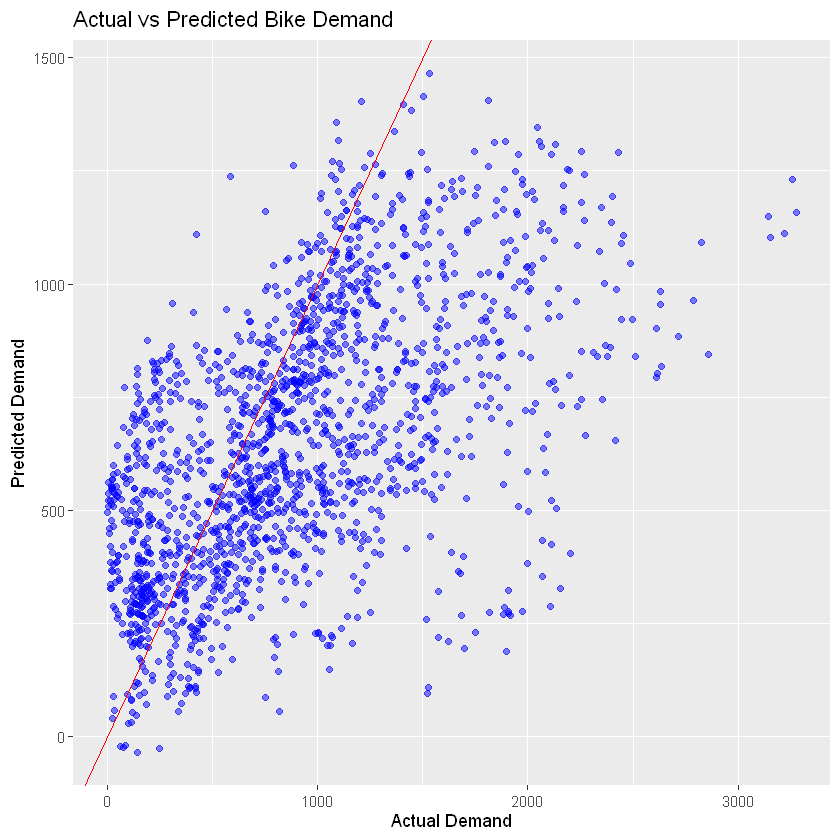

In [7]:
# Create comparison plot

ggplot(data = data.frame(
  actual = test_data$rented_bike_count,
  predicted = predictions
), aes(x = actual, y = predicted)) +
  geom_point(color = "blue", alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, color = "red") +
  labs(
    title = "Actual vs Predicted Bike Demand",
    x = "Actual Demand",
    y = "Predicted Demand"
  )

## Interpretation

From the baseline model:

- Weather variables explain a portion of bike demand variability
- The model provides a reasonable starting point
- However, it may not capture complex patterns such as:
  - Time-based variations
  - Non-linear relationships

This motivates further model refinement in the next stage.

---

## Author & Acknowledgment

**Author:**  
<span style="color:blue">Deepan Mehta </span>  

**GitHub Profile:**  
https://github.com/deepan-mehta-analytics

This notebook focuses on building and evaluating a baseline linear regression model using weather-related features.

The workflow follows <span style="color:blue">IBM Skills Network </span> instructional labs on regression modeling and baseline model development.

Special acknowledgment is given to:

- <span style="color:blue">Yan Luo </span>  
- <span style="color:blue">Jeff Grossman</span>  
- <span style="color:blue">Rav Ahuja et al. at the IBM Skills Network</span>  

---

## Project Context

This notebook represents the baseline modeling stage in the end-to-end data science pipeline:

- Data Collection  
- Data Wrangling (ETL)  
- Exploratory Data Analysis (EDA)  
- **Baseline Model Development**  
- Model Refinement  
- Model Evaluation  
- Deployment (R Shiny Dashboard)

---

## Notes

This baseline model serves as a reference point for evaluating improvements introduced in subsequent modeling stages.

---